# Linear Regression

*Regression analysis* is a common statistical process for estimating the relationships between variables. This can allow us to make numeric predictions based on existing training data. 

In [55]:
import random
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

## Example 1: Simple Linear Regression

*Simple Linear Regression* predicts a numeric response variable based on a single input variable (feature).

To demonstrate the use of simple linear regression with sci-kit learn, we will first create sample random data. 

In [56]:
x_values = [random.random() for _ in range(15)]
#y_values = [3 * x + 2 for x in x_values]
y_values = [3 * x + 2 + random.gauss(0, 1) for x in x_values]
# turn the values into a DataFrame
df1 = pd.DataFrame({'X': x_values, 'Y': y_values})
df1.head()

,X,Y
0,0.909679,4.529538
1,0.792236,3.428444
2,0.237127,1.832286
3,0.469673,3.263261
4,0.591008,4.615714


First, let's plot the data:

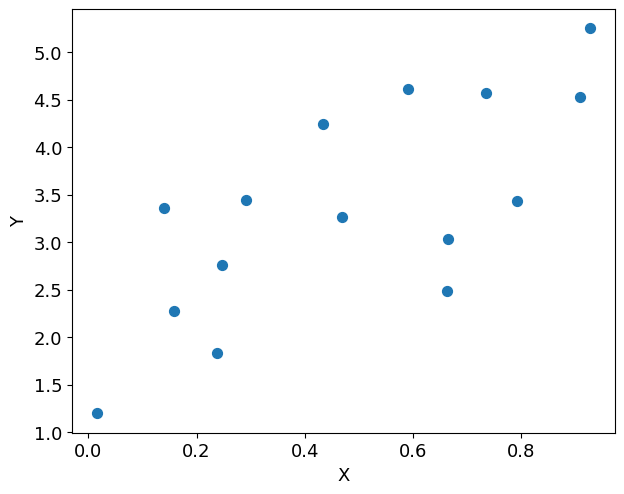

In [57]:
ax = df1.plot.scatter("X", "Y", s=50, figsize=(7, 5.5), fontsize=13)
ax.set_xlabel("X", fontsize=13)
ax.set_ylabel("Y", fontsize=13);
plt.show()

Apply simple linear regression to learn (fit) the model, where *X* is our input variable and *Y* is the target variable that we would like to learn how to predict:

In [58]:
model = LinearRegression()
# extract the column to use our input variable
x = df1[["X"]].values
# extract the column to use as our target variable
y = df1[["Y"]].values
# fit the model
m = model.fit(x, y)

Note the use of the [["X"]] notation above to extract the values from df1. This is needed because the sklearn library works with 2D data structures.

If you use df["X"] it will return a Panda Series of shape (n).

By using df[["X"]] a 2D Panda Dateframe of shape (n, 1) is returned. 


Display the model parameters that we have learned: 

In [59]:
print("Model intercept is %.4f" % model.intercept_[0])
print("Model slope is %.4f" % model.coef_[0][0])

Model intercept is 1.9915
Model slope is 2.8088


This model can now be use to make predictions for *y* given new values of *x*:

In [60]:
# make a prediction for a single example
x_unseen = [[0.78]]
model.predict(x_unseen)

array([[4.18244327]])

In [61]:
# make a prediction for several examples
x_unseen = [[0.78], [0.89], [0.81]]
model.predict(x_unseen)

array([[4.18244327],
       [4.49141672],
       [4.26670876]])

Again note the use of the [[  ]] notation in the above examples. 


Plot the original data and the model's regression line:

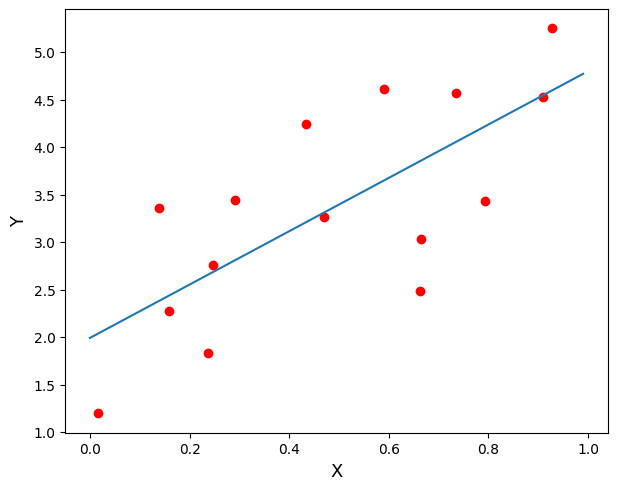

In [62]:
# create predictions which we will use to generate our line
X_fit = [[i / 100] for i in range(100)]
y_fit = model.predict(X_fit)
# plot the data
plt.figure(figsize=(7, 5.5))
plt.scatter(x, y, marker="o", c="red")
# plot the line
plt.plot(X_fit, y_fit)
plt.xlabel("X", fontsize=13)
plt.ylabel("Y", fontsize=13);
plt.show()

## Example 2: Simple Linear Regression

As a second example, we will examine a dataset of 244 restaurant meals, with details of total meal bill and the corresponding tip amount.

In [63]:
df2 = pd.read_csv("tips.csv")
df2.head(5)

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


First, let's plot the data using Matplotlib:

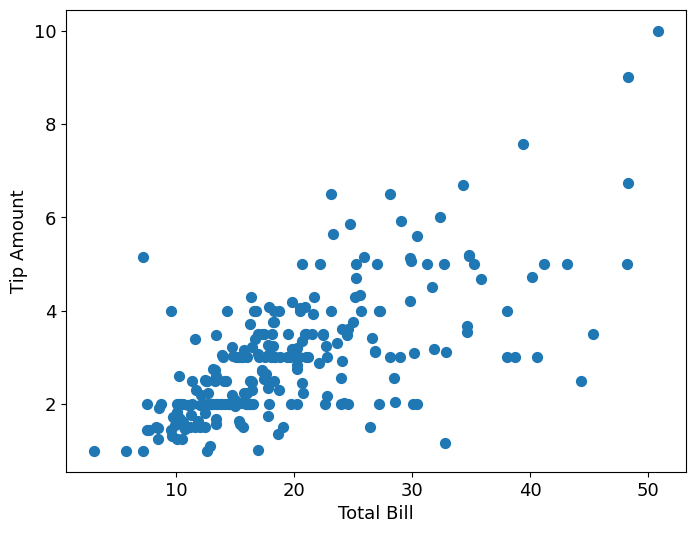

In [64]:
ax = df2.plot.scatter("total_bill", "tip", s=50, figsize=(8, 6), fontsize=13)
plt.xlabel("Total Bill", fontsize=13)
plt.ylabel("Tip Amount", fontsize=13);
plt.show()


From the above, it seems there is a reasonably strong relationship. Let's quantify the level of correlation between the two variables.

In [65]:
df2.corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


We could also look at a boxplot of the data, to see if there are outlying values:

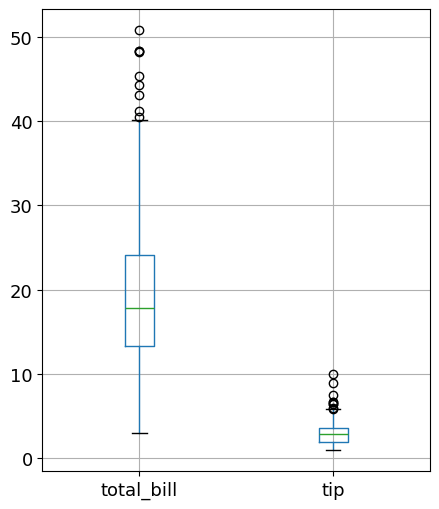

In [66]:
df2.boxplot(figsize=(5, 6), fontsize=13);
plt.show()

Now, apply simple linear regression to learn (fit) the model, where *x* (the total bill) is our independent variable and *y* (the tip amount) is the target variable that we would like to learn how to predict:

In [67]:
# note, we need to extract the columns as DataFrames, not Series
x = df2[["total_bill"]].values
y = df2[["tip"]].values

In [68]:
# now build the regression model
model = LinearRegression()
m = model.fit(x, y)

Look at the parameters of the model we learned (the regression line):

In [69]:
print("Model intercept is %.4f" % model.intercept_[0])
print("Model slope is %.4f" % model.coef_[0][0])

Model intercept is 0.9203
Model slope is 0.1050


Now let's plot the data again, adding our regression line

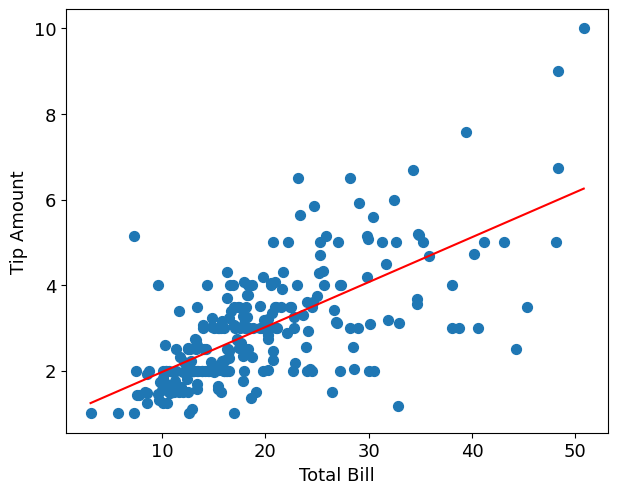

In [70]:
# plot the data
ax = df2.plot.scatter("total_bill", "tip", s=50, figsize=(7, 5.5), fontsize=13)
# plot the regression line
m = model.coef_[0]
b = model.intercept_
plt.plot([min(x), max(x)], [m*min(x)+b, m*max(x)+b], 'r')
plt.xlabel("Total Bill", fontsize=13)
plt.ylabel("Tip Amount", fontsize=13);
plt.show()

We can make predictions from this model for unseen bill examples:

In [71]:
unseen_bills = list(range(10, 70, 10))
for bill in unseen_bills:
    unseen_example = [[bill]]
    predict_tip = model.predict(unseen_example)
    print("Predicted tip for meal costing %.2f = %.2f" % (bill,  predict_tip[0][0]))

Predicted tip for meal costing 10.00 = 1.97
Predicted tip for meal costing 20.00 = 3.02
Predicted tip for meal costing 30.00 = 4.07
Predicted tip for meal costing 40.00 = 5.12
Predicted tip for meal costing 50.00 = 6.17
Predicted tip for meal costing 60.00 = 7.22


We can also compare the outputs of our model, with the original data to see if it agrees (note: normally we would use a separate test dataset in a real evaluation).

   Predicted Tip  Actual Tip
0       2.704636        1.01
1       2.006223        1.66
2       3.126835        3.50
3       3.407250        3.31
4       3.502822        3.61


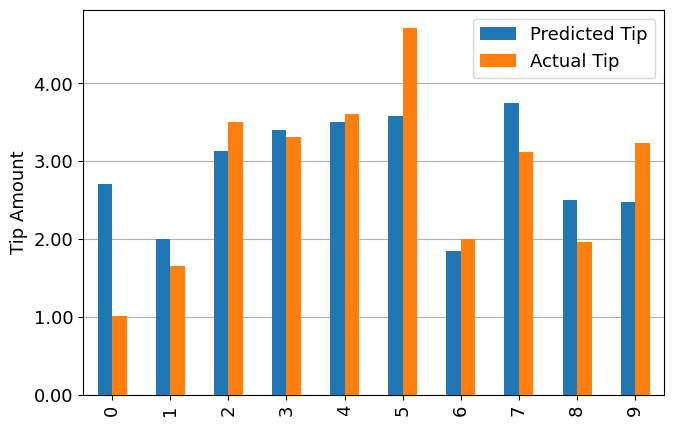

In [72]:
# let's just make predictions for 10 rows

comparison = []
for i in range(10):
    # the input variable (the cost of the meal). Extract the relevant value from the 2D array, x
    test_x = x[i][0] 
    # use the model to predict y. Extract predict predict_y from the 2D array returned by the model
    predict_y = model.predict([[test_x]])[0][0]
    # the correct answer
    actual_y = y[i][0]
    comparison.append( {"Predicted Tip": predict_y, "Actual Tip": actual_y} )

# Convert the comparison list into a Data Frame
df_comparison = pd.DataFrame(comparison)
print(df_comparison.head())

# display the results as a bar chart
ax = df_comparison.plot(kind="bar", figsize=(7.5, 5), fontsize=13, zorder=3)
ax.yaxis.grid(True)
ax.legend(fontsize=13)
ax.set_ylabel("Tip Amount", fontsize=13)
ax.yaxis.set_major_formatter("{x:.2f}");
plt.show()

We can calculate the overall *mean squared error* between the predictions and the actual profit numbers. This gives us an idea of how well the model based on R&D spend predicts profit (based on our current data). Scikit-learn includes a function to calculate this for us:

## Example 3: Multiple Linear Regression

In our final example, we will use a dataset from a bike sharing company, which reports the number of rentals per day and the weather conditions on that day. The goal is to predict the number of rentals per day, based on weather conditions.

The features we will consider are:
- *temp*: normalized temperature in Celsius
- *atemp*: normalized "real feel" temperature in Celsius
- *hum*: normalized humidity level
- *windspeed*: normalized wind speed
- *count*: count of total rental bikes rented on this day

Original data source: https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset

In [73]:
df5 = pd.read_csv("bikesharing.csv", index_col=0)
df5.head(5)

,temp,atemp,hum,windspeed,count
day,,,,,
1,0.344167,0.363625,0.805833,0.160446,985
2,0.363478,0.353739,0.696087,0.248539,801
3,0.196364,0.189405,0.437273,0.248309,1349
4,0.200000,0.212122,0.590435,0.160296,1562
5,0.226957,0.229270,0.436957,0.186900,1600


We will first look at the correlations between the different variables in the data. Unsurprisingly, we see that the temperature and "real feel" temperature values are very highly correlated.

In [74]:
df5.corr()

,temp,atemp,hum,windspeed,count
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
count,0.627494,0.631066,-0.100659,-0.234545,1.000000


We remove the "count" column that we are going to predict. This will be our response (dependent) variable. We keep this separate from the weather variables used to make the predictions (i.e. the independent variables).

In [75]:
y = df5["count"]
X = df5.drop("count", axis=1)
X.head()

,temp,atemp,hum,windspeed
day,,,,
1,0.344167,0.363625,0.805833,0.160446
2,0.363478,0.353739,0.696087,0.248539
3,0.196364,0.189405,0.437273,0.248309
4,0.200000,0.212122,0.590435,0.160296
5,0.226957,0.229270,0.436957,0.186900


We will train our regression model on 70% of the examples, and keep 30% of the examples aside to test the model. These examples are not made available to the regression algorithm during training.

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
print("%d training examples, %d test examples" % (X_train.shape[0], X_test.shape[0]))

511 training examples, 220 test examples


Build the regression model on the training data:

In [77]:
model = LinearRegression()
m = model.fit(X_train, y_train)

Check the coefficients of the model that we have trained. Note that we have 4 coeffecients in this case:

In [78]:
pd.DataFrame(model.coef_, X.columns, columns=['Coefficients'])

,Coefficients
temp,3797.619619
atemp,3055.386653
hum,-3565.231745
windspeed,-4772.861413


Now make the predictions for the testing data to predict the number of rentals:

In [79]:
y_pred = model.predict(X_test)
print("Made predictions for %d test examples" % y_pred.shape[0])

Made predictions for 220 test examples


We can quantitatively look at the level of error in the perdictions by calculating the mean squared error:

In [80]:
mse = mean_squared_error(y_test, y_pred)
print("MSE=%.2f" % mse)

MSE=2082705.86


Finally, we can generate a scatter plot of our predictions versus actual rental counts for the test examples:

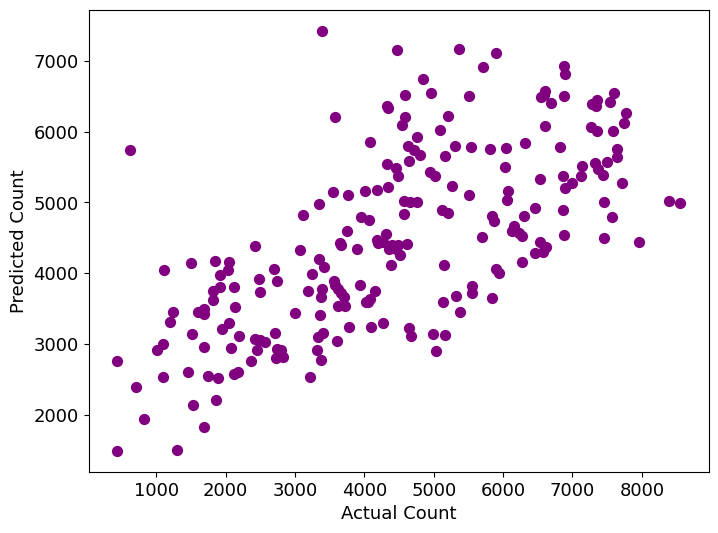

In [81]:
df_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
ax = df_comparison.plot.scatter("Actual", "Predicted", fontsize=13, figsize=(8, 6), s=50, color="purple")
plt.xlabel("Actual Count", fontsize=13)
plt.ylabel("Predicted Count", fontsize=13);
plt.show()